In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
names = open("names.txt", 'r').read().splitlines()

In [3]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

eg word isabella



1.  i is very likely to come first
2.  s likely to come after i
3.  a likely to to come after is
4.  ...
5.  ....
6.  after the letter a the word is likely to end

In [4]:
len(names)

32033

In [5]:
min(len(w) for w in names)

2

In [6]:
min(names, key = len)

'an'

In [7]:
max(len(n) for n in names)

15

In [8]:
max(names, key = len)

'muhammadibrahim'

In [9]:
b = {}
for n in names:
    n = ['<S>'] + list(n) + ['<E>']
    for ch1, ch2 in zip(n, n[1:]):
      bigram = (ch1, ch2)
      b[bigram] = b.get(bigram, 0) + 1
      # print(ch1, ch2)

In [10]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [11]:
b = sorted(b.items(), key = lambda kv: kv[1], reverse=True)

In [12]:
# @title
b

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [13]:
chars = sorted(list(set(''.join(names))))

In [14]:
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s, i in stoi.items()}

# Cleaning up special tokens

In [15]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [16]:
for n in names:
    n = ['.'] + list(n) + ['.']
    for ch1, ch2 in zip(n, n[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      N[ix1, ix2] += 1

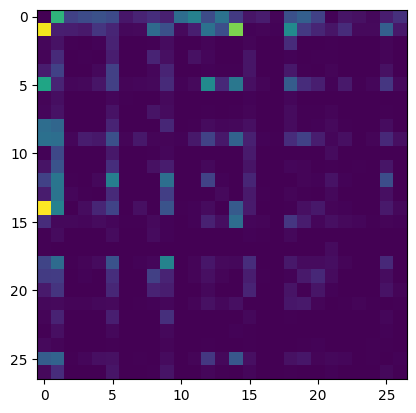

In [17]:
plt.imshow(N)

# Display chart of counts

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

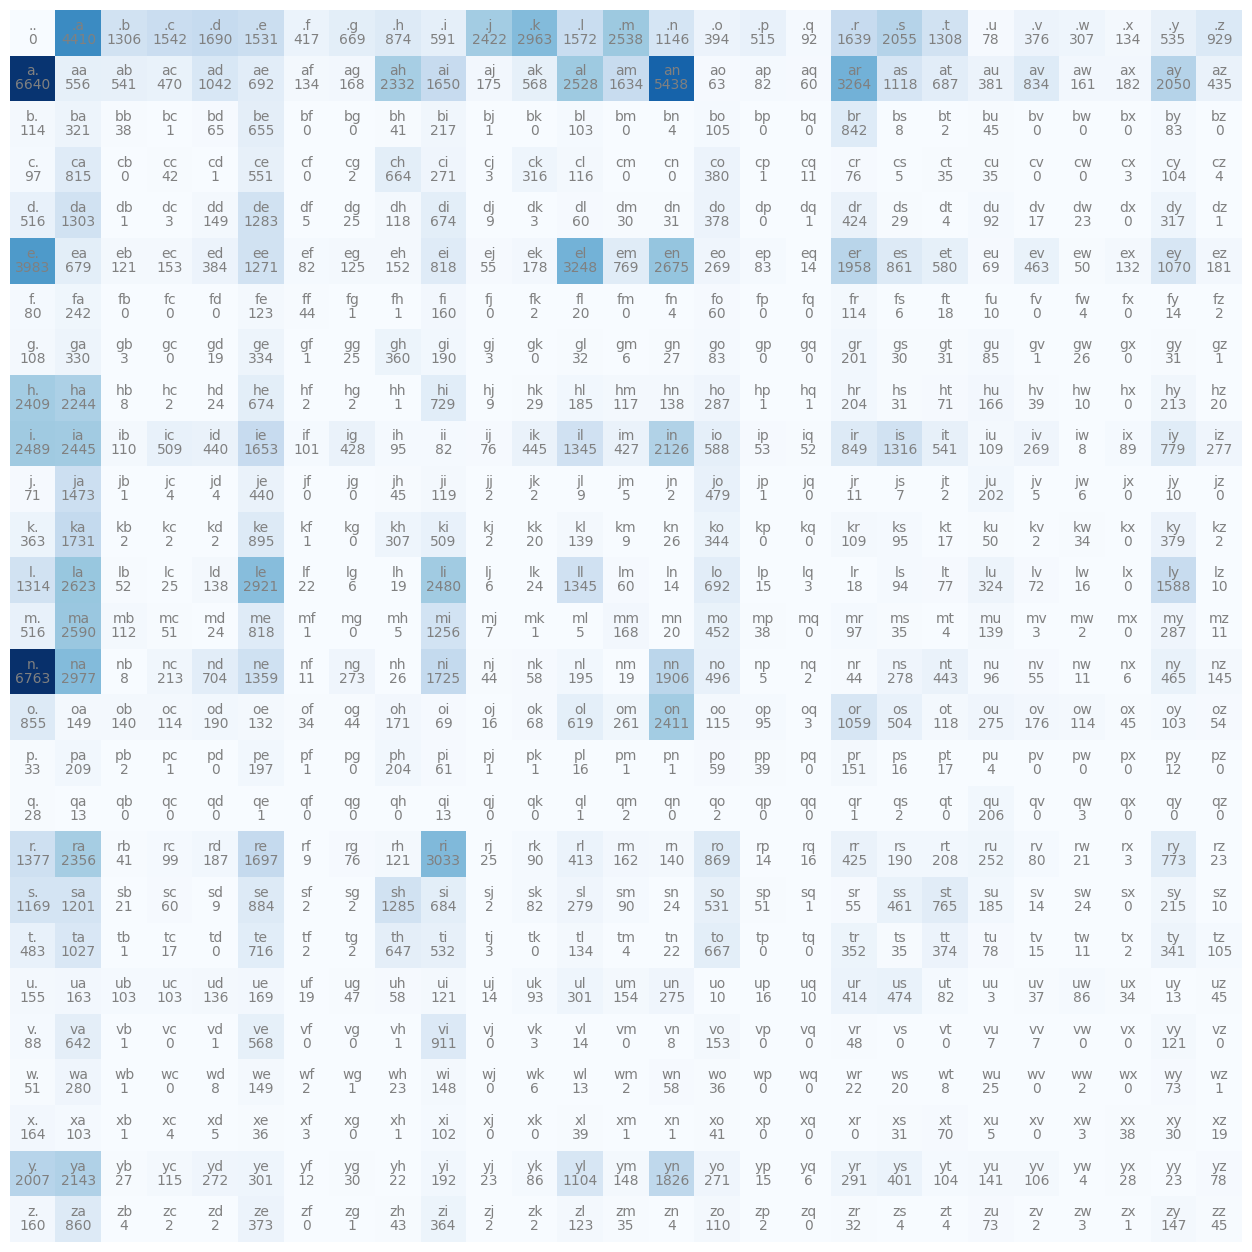

In [18]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

plt.axis('off')

In [19]:
N.sum(1, keepdim=True)

tensor([[32033],
        [33885],
        [ 2645],
        [ 3532],
        [ 5496],
        [20423],
        [  905],
        [ 1927],
        [ 7616],
        [17701],
        [ 2900],
        [ 5040],
        [13958],
        [ 6642],
        [18327],
        [ 7934],
        [ 1026],
        [  272],
        [12700],
        [ 8106],
        [ 5570],
        [ 3135],
        [ 2573],
        [  929],
        [  697],
        [ 9776],
        [ 2398]])

## Optimize to not renormalize in each iteration

https://pytorch.org/docs/stable/notes/broadcasting.html

Rules to check broadcast compatibility:


1.   Right align dimensions of the two arrays<br>
2.   Starting from right to left check the following:<br>

    *   either both dimensions of equal size
    *   either of the dimensions is 1
    *   either of the dimensions doesn't exist


eg.
p [27] broadcasted over m [27,27]  



*   27 27<br>
    "  "  27      --> Autoassumes the missing dimension to be 1
    m/p becomes row-duplication division. i.e. the same [1, 27] row duplicated vertically and divided element wise with the [27,27]  array
*   [1, 27] broadcasted over [27,27]  
    m/p becomes row-duplication division. i.e. the same [1, 27] row duplicated down and divided element wise with the [27,27]  array

*   [27, 1] broadcasted over [27,27]  
    m/p becomes column-duplication division. i.e. the same [27, 1] column duplicated across and divided element wise with the [27,27]  array



## Importance of keepdim when summing up each row

If keepdim is False, the collapsed dimension is removed leaving the final sum to be a single vector/array of 27 elements. Then when broadcasting during the divide point #2 gets applied and each individual element in the row does not get divided by the same sum(sum of elements in corresponding row)

If keepdim is True, the collapsed dimension is retained and hence the final shape is [27, 1], broadcasting rule in #3 then gets applied - which is the correct division.

In [20]:
P = N.float()
P /= P.sum(1, keepdim=True)

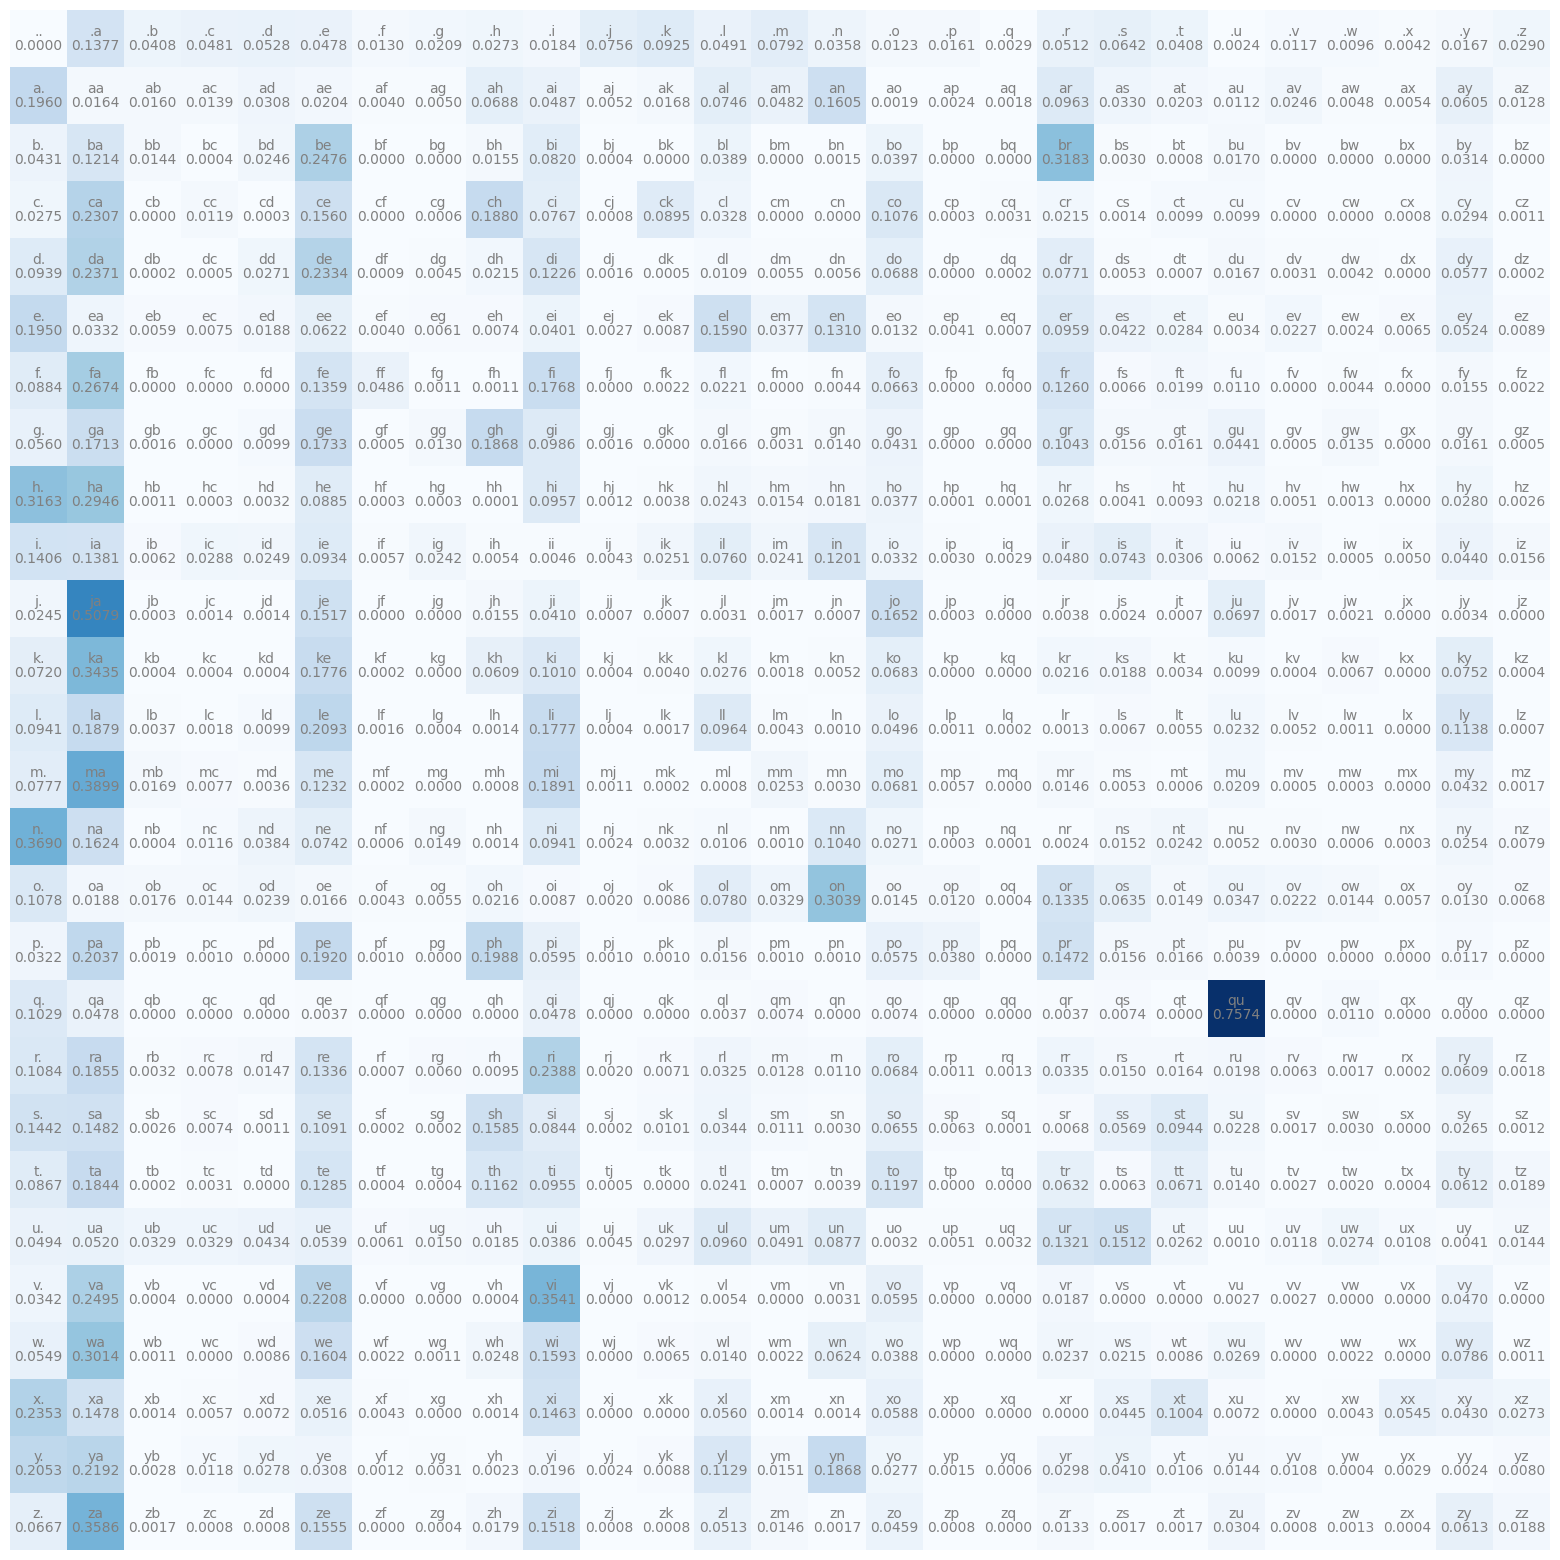

In [21]:
plt.figure(figsize=(20, 20))
plt.imshow(P, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, f"{P[i, j].item():.4f}", ha="center", va="top", color='gray')
plt.axis('off');

p = p/p.sum() allocates new memory to the new p that the result is assigned to.

More efficient to do p/=p.sum()

In [22]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/p.sum()
p


tensor([0.6064, 0.3033, 0.0903])

In [23]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g) ## drawing 0 with prob 0.6064, drawing 1 with prob 0.3033, drawing 2 with prob 0.0903

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

Similar generator can be used for generating names

In [24]:
p = N[0].float()
p = p/p.sum()
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
itos[ix]

'c'

In [25]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
    if itos[ix] == '.':
      break
    out.append(itos[ix])
  print("".join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## Testing the same model on a probability distribution that is constant across all letters

Clearly doesn't generate anything "learnt"

In [26]:
E = torch.ones(27,27).float()
E = E/27

In [27]:
for i in range(10):
  ix = 0
  while True:
    p = E[ix]
    ix = torch.multinomial(p, 1, replacement=True).item()
    if itos[ix] == '.':
      break
    print(itos[ix], end='')
  print("\n")

bbpuawirxoqolqqwszkongvkstdamorb

raqqqsveyujkiconrftblvqayp

dirtageicmwwjpvqvhfpbxxsvcchq

smvrbzovzqiokjychtfmsxemwl

wwuk

cdkikdymccnqduzogyf

jpzifrihlkjwqdbpqorphrw

uymyamje

yfcyypeuy

ffpfd



# Evaluation: coming up with a loss based on MLE

What is the likelihood of our dataset in `names.txt` existing given the current model??

L = 𝚷 (prob of each name across the dataset) = 𝚷 (generating a name by drawing corresponding bigrams)

In [28]:
for name in names[:3]:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    print(ch1, ch2, f"{prob:.4f}")


. e 0.0478
e m 0.0377
m m 0.0253
m a 0.3899
a . 0.1960
. o 0.0123
o l 0.0780
l i 0.1777
i v 0.0152
v i 0.3541
i a 0.1381
a . 0.1960
. a 0.1377
a v 0.0246
v a 0.2495
a . 0.1960


Probability of the name Emma then becomes

In [29]:
emma = names[0]
char = ['.'] + list(emma) + ['.']
running_prob = 1
for ch1, ch2 in zip(char, char[1:]):
  ix1 = stoi[ch1]
  ix2 = stoi[ch2]
  prob = P[ix1, ix2]
  print(ch1, ch2, prob)
  running_prob *= prob

print(running_prob)

. e tensor(0.0478)
e m tensor(0.0377)
m m tensor(0.0253)
m a tensor(0.3899)
a . tensor(0.1960)
tensor(3.4782e-06)


But the likelihood suffers from the problem of "vanishing"

So good to use log-likelihood

In [30]:
emma = names[0]
char = ['.'] + list(emma) + ['.']
running_logprob = 0
for ch1, ch2 in zip(char, char[1:]):
  ix1 = stoi[ch1]
  ix2 = stoi[ch2]
  prob = P[ix1, ix2]
  print(ch1, ch2, prob)
  running_logprob += torch.log(prob)

print(running_logprob)

. e tensor(0.0478)
e m tensor(0.0377)
m m tensor(0.0253)
m a tensor(0.3899)
a . tensor(0.1960)
tensor(-12.5690)


Log is a monotonically increasing function that maxes out at 1.
log(1) is 0

Best log prob is when the likelihood of the data is 1 i.e log prob is 0.
This makes the problem a maximizing problem.

Maximizing is for losers! So we minimize negative log prob instead.

In [31]:
nll = -running_logprob
print(nll)

tensor(12.5690)


Probability of the entire dataset

In [32]:
running_logprob = 0
for name in names:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    running_logprob += torch.log(prob)

print(f"{running_logprob=}")

running_logprob=tensor(-559891.7500)


Avg it out

In [33]:
running_logprob = 0
n = 0
for name in names:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    n +=1
    running_logprob += torch.log(prob)

nll = -running_logprob/n
print(f"{nll=}")

nll=tensor(2.4541)


Find out the likelihood of your name under this model

In [34]:
running_logprob = 0
n = 0
for name in ['snehal']:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    print(ch1, ch2, prob)
    n +=1
    running_logprob += torch.log(prob)

nll = -running_logprob/n
print(f"{nll=}")

. s tensor(0.0642)
s n tensor(0.0030)
n e tensor(0.0742)
e h tensor(0.0074)
h a tensor(0.2946)
a l tensor(0.0746)
l . tensor(0.0941)
nll=tensor(3.1788)


But what if your name had a combination that has a zero probability in the datasest??


In [35]:
running_logprob = 0
n = 0
for name in ['snehxal']:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    # print(ix1, ix2, P[ix1, ix2])
    print(ch1, ch2, prob, torch.log(prob) )
    n +=1
    running_logprob += torch.log(prob)

nll = -running_logprob/n
print(f"{nll=}")

. s tensor(0.0642) tensor(-2.7465)
s n tensor(0.0030) tensor(-5.8223)
n e tensor(0.0742) tensor(-2.6016)
e h tensor(0.0074) tensor(-4.9005)
h x tensor(0.) tensor(-inf)
x a tensor(0.1478) tensor(-1.9121)
a l tensor(0.0746) tensor(-2.5955)
l . tensor(0.0941) tensor(-2.3630)
nll=tensor(inf)



then nll = infinity! So important to do +1 smoothing(**pre-normalization**)

In [36]:
P = (N+1).float()

P /= P.sum(1, keepdim=True)

In [37]:

running_logprob = 0
n = 0
for name in ['snehxal']:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    # print(ix1, ix2, P[ix1, ix2])
    print(ch1, ch2, prob)
    n +=1
    running_logprob += torch.log(prob)

nll = -running_logprob/n
print(f"{nll=}")

. s tensor(0.0641)
s n tensor(0.0031)
n e tensor(0.0741)
e h tensor(0.0075)
h x tensor(0.0001)
x a tensor(0.1436)
a l tensor(0.0746)
l . tensor(0.0940)
nll=tensor(3.9839)


Now this over the entire dataset

In [38]:

running_logprob = 0
n = 0
for name in names:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    # print(ix1, ix2, P[ix1, ix2])
    # print(ch1, ch2, prob)
    n +=1
    running_logprob += torch.log(prob)

nll = -running_logprob/n
print(f"{running_logprob=}")
print(f"{nll=}")

running_logprob=tensor(-559951.5625)
nll=tensor(2.4544)


# Doing it the Neural Net way (goal is to achieve same loss 2.4544)

first character in bigram is the input and the character that follows it is the output.<br>
We need to drive these output prediction probabilities as close to the ground truth probabilities as possible.<br>
Achieve this using gradient descent by minimizing the NLL on the output.







## step 1: create a training dataset from the names

In [39]:
xs, ys = [], []

for name in names[:1]:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)



Difference between torch.tensor and torch.Tensor is that the lowercase one infers dtype by default based on the input, while the uppercase one defaults to float32

In [40]:
xt = torch.tensor(xs)
xt.dtype

torch.int64

In [41]:
xT = torch.Tensor(xs)
xT.dtype

torch.float32

Continue using torch.tensor

In [42]:
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [43]:
xs[:5]

tensor([ 0,  5, 13, 13,  1])

In [44]:
xs.shape

torch.Size([5])

Cannot input integers directly into the neural net, need to one-hot encode it first!

input to one-hot needs to be int64, so make sure not to float cast before one-hot


In [45]:
xenc = torch.nn.functional.one_hot(xs, num_classes=27)
xenc.shape

torch.Size([5, 27])

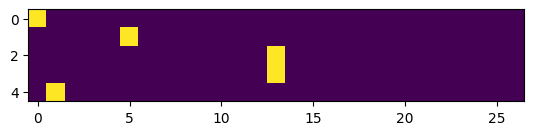

In [46]:
plt.imshow(xenc)

In [47]:
W = torch.randn((27, 1))
# i.e this is a single neuron taking in a 27 length vector as input
# which is the 27-length one hot encoding of a single input

In [48]:
W.shape

torch.Size([27, 1])

In [49]:
xenc @ W

RuntimeError: expected m1 and m2 to have the same dtype, but got: long int != float

We want the input to a neural net to be floats for dot-product compatibility with weights

In [50]:
xenc.dtype, W.dtype

(torch.int64, torch.float32)

In [51]:
xenc = xenc.float()

In [52]:
xenc @ W

tensor([[-0.7900],
        [ 1.0111],
        [ 1.0358],
        [ 1.0358],
        [-1.5477]])

Let's have 27 output neurons instead. that way each will correspond to a output probability of the next character

In [53]:
W = torch.randn((27, 27))
xenc @ W

tensor([[ 0.1844, -0.7287,  1.0081, -0.2709, -0.7711,  0.4074, -0.0302, -0.4870,
          1.4758,  0.6274,  0.2225, -0.1859,  0.2321,  0.4877, -0.0348,  0.6620,
         -0.6697,  0.6764,  0.3968, -0.1984, -0.9681, -0.7743, -0.0523, -0.9812,
          0.3028,  0.9309, -1.8343],
        [-0.1991, -0.3184,  0.5294,  0.4138,  0.1183, -0.4720,  1.5322,  0.2248,
         -0.4752,  0.0106,  2.6425, -0.8196, -0.2448, -0.7276, -0.5910, -0.6024,
         -0.0600,  0.3887,  0.0202, -1.1964,  0.5593, -0.1909,  1.3702, -1.7189,
          1.8356,  0.1919, -2.4356],
        [-0.8012, -0.6912,  0.4635, -0.0687,  0.6186,  1.8787, -0.9525,  0.1176,
         -0.8532, -0.3914,  0.4882, -0.5836, -0.9451, -0.8217, -0.2554,  0.4538,
          0.2444,  1.0057,  0.2308, -0.1975,  0.4139,  0.3325,  0.3017,  0.9275,
          0.8404,  0.7210, -0.3800],
        [-0.8012, -0.6912,  0.4635, -0.0687,  0.6186,  1.8787, -0.9525,  0.1176,
         -0.8532, -0.3914,  0.4882, -0.5836, -0.9451, -0.8217, -0.2554,  0.4538

# So how do we interpret these numbers

1) As counts?? no, coz counts are integers<br>
2) Probabilities ?? no, coz probabilities are all positive and should sum up to 1 <br>
3) Log Counts!! i.e. Logits<br>

Simply exponentiating these log counts will give us the equivalent of counts in the original grid

In [54]:
(xenc @ W).exp() # values ranging from 0 to inf --> equivalent to the N matrix of couunts

tensor([[ 1.2026,  0.4825,  2.7404,  0.7627,  0.4625,  1.5029,  0.9702,  0.6145,
          4.3746,  1.8728,  1.2492,  0.8304,  1.2613,  1.6285,  0.9658,  1.9387,
          0.5119,  1.9668,  1.4871,  0.8201,  0.3798,  0.4610,  0.9490,  0.3749,
          1.3536,  2.5368,  0.1597],
        [ 0.8195,  0.7273,  1.6979,  1.5126,  1.1256,  0.6238,  4.6282,  1.2521,
          0.6218,  1.0106, 14.0481,  0.4406,  0.7829,  0.4830,  0.5537,  0.5475,
          0.9418,  1.4751,  1.0204,  0.3023,  1.7494,  0.8262,  3.9362,  0.1793,
          6.2689,  1.2115,  0.0875],
        [ 0.4488,  0.5010,  1.5896,  0.9336,  1.8564,  6.5449,  0.3858,  1.1248,
          0.4260,  0.6761,  1.6294,  0.5579,  0.3886,  0.4397,  0.7746,  1.5743,
          1.2769,  2.7337,  1.2596,  0.8208,  1.5127,  1.3944,  1.3521,  2.5281,
          2.3173,  2.0565,  0.6839],
        [ 0.4488,  0.5010,  1.5896,  0.9336,  1.8564,  6.5449,  0.3858,  1.1248,
          0.4260,  0.6761,  1.6294,  0.5579,  0.3886,  0.4397,  0.7746,  1.5743

We need to softmax the logits to convert them to regular probabilities

In [55]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)


In [56]:
probs

tensor([[0.0355, 0.0143, 0.0809, 0.0225, 0.0137, 0.0444, 0.0287, 0.0181, 0.1292,
         0.0553, 0.0369, 0.0245, 0.0372, 0.0481, 0.0285, 0.0573, 0.0151, 0.0581,
         0.0439, 0.0242, 0.0112, 0.0136, 0.0280, 0.0111, 0.0400, 0.0749, 0.0047],
        [0.0168, 0.0149, 0.0347, 0.0309, 0.0230, 0.0128, 0.0947, 0.0256, 0.0127,
         0.0207, 0.2874, 0.0090, 0.0160, 0.0099, 0.0113, 0.0112, 0.0193, 0.0302,
         0.0209, 0.0062, 0.0358, 0.0169, 0.0805, 0.0037, 0.1283, 0.0248, 0.0018],
        [0.0119, 0.0133, 0.0421, 0.0247, 0.0491, 0.1732, 0.0102, 0.0298, 0.0113,
         0.0179, 0.0431, 0.0148, 0.0103, 0.0116, 0.0205, 0.0417, 0.0338, 0.0723,
         0.0333, 0.0217, 0.0400, 0.0369, 0.0358, 0.0669, 0.0613, 0.0544, 0.0181],
        [0.0119, 0.0133, 0.0421, 0.0247, 0.0491, 0.1732, 0.0102, 0.0298, 0.0113,
         0.0179, 0.0431, 0.0148, 0.0103, 0.0116, 0.0205, 0.0417, 0.0338, 0.0723,
         0.0333, 0.0217, 0.0400, 0.0369, 0.0358, 0.0669, 0.0613, 0.0544, 0.0181],
        [0.0402, 0.0301,

# Putting it all together makes a FORWARD PASS

all operations differentiable

In [57]:
xs, ys = [], []

for name in names[:1]:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

xenc = torch.nn.functional.one_hot(xs, num_classes=27).float()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

# Let's talk about each component

In [58]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print(f'label (actual next character): {y} ({itos[y]})')
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', probs[i, y].item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5 (e)
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13 (m)
probability assigned by the net to the the correct chara

so log-probs --> exponentiate --> softmax(log-probs) --> re-log for log likelihood --> nll

# Now let's backpropagate

Very similar to micrograd backprop, except the loss function used is nll and not mse, since this is a classification problem not a regression problem.


In [59]:
ys

tensor([ 5, 13, 13,  1,  0])

We want the probabilities of the first input's output at position/index 5, coz we want the probability of the 5th character being output

so probs[0, 5]

In [60]:
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

Our loss function here is only taking into account the probability outputs corresponding to expected labels, this essentially drives the value at that position to be 1

[a b 0.5 c d ...] vs [0 0 1 0 0 ...]
we take log(0.5) and not sum over log(a/b/c/d) which we want to drive down to 0

However this argument does not work, since ideal values of a/b/c/d are 0, which would make log(a/b/c/d) -inf, this would make the loss intractable around ideal values.

In [61]:
probs[torch.arange(5), ys]

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150])

In [62]:
avg_nll = -probs[torch.arange(5), ys].log().mean().item()

In [63]:
loss = avg_nll
loss

3.7693049907684326

Made it upto the loss in the forward pass

In [64]:
xs, ys = [], []

for name in names[:1]:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

xenc = torch.nn.functional.one_hot(xs, num_classes=27).float()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) ## requires_grad set here


### Make sure requires grad on W is true 👆

In [65]:
# forward pass
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [66]:
print(loss.item())

3.7693049907684326


In [67]:
# backward pass
W.grad = None ## zero grad
loss.backward()

In [68]:
W.shape, W.grad.shape

(torch.Size([27, 27]), torch.Size([27, 27]))

In [69]:
W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [70]:
# weight update

W.data += -0.1 * W.grad

# Gradient Descent using the entire dataset

In [71]:
xs, ys = [], []

for name in names:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()
print('num of examples: ',num)

xenc = torch.nn.functional.one_hot(xs, num_classes=27).float()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

num of examples:  228146


In [72]:
xenc.shape

torch.Size([228146, 27])

In [73]:
for k in range(100):
  # forward pass
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)
  loss = -probs[torch.arange(num), ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None ## zero grad, make sure requires grad on W is true
  loss.backward()

  # weight update
  W.data += -75 * W.grad

3.758953809738159
3.231318712234497
3.008704900741577
2.882441520690918
2.80303955078125
2.7484331130981445
2.7077155113220215
2.676027536392212
2.6504580974578857
2.6296050548553467
2.6122474670410156
2.5977776050567627
2.585455894470215
2.5749828815460205
2.5658633708953857
2.5579750537872314
2.5509660243988037
2.5448172092437744
2.5392608642578125
2.534337282180786
2.5298283100128174
2.5258092880249023
2.5220882892608643
2.518760919570923
2.515650987625122
2.512864828109741
2.5102357864379883
2.5078794956207275
2.505634069442749
2.50362229347229
2.501685619354248
2.499952793121338
2.49826717376709
2.496762752532959
2.4952826499938965
2.4939661026000977
2.4926559925079346
2.4914956092834473
2.490328073501587
2.4892990589141846
2.488250970840454
2.487332582473755
2.4863858222961426
2.485563039779663
2.4847028255462646
2.483961582183838
2.483175754547119
2.4825050830841064
2.4817845821380615
2.4811758995056152
2.4805121421813965
2.4799580574035645
2.479343891143799
2.478837728500366
2.

# So what's the benefit of doing this the NN way when the Counting way also gives the same result

--> NN more flexible can do the same thing for more complex dataset and adapt the NN to be more complex

--> becomes infeasible when we have more and more complicated data trigram, more grams

# More equivalence and analogy between NN and Naive

since we are using one-hot encoding, every input only ends up picking out corresponding row of the weight vector during dot product - essentially zeroing out all other rows or characters

this is exactly what was happening in the Naive approach, where we picked out the probability distribution row where the current character was the first character and then multinomialed over that row

# Now let's generate names

In [74]:
########## WRONG ################

g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  ix = 0
  out = []

  while True:
    # p = P[ix]
    logits = xenc @ W #--> you need to encode ix = 0 the start character
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    if ix==0:
      print(probs.shape) #--> shape  [228146, 27] and then you're indexing from (train dataset+param) W

    # print(probs[ix])
    # ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
    ix = torch.multinomial(probs[ix], 1, replacement=True, generator=g).item()
    if itos[ix] == '.':
      break
    out.append(itos[ix])
  print("".join(out))

torch.Size([228146, 27])
cexba
torch.Size([228146, 27])
mhalkuraiiaziayhnekljlmjtraierlknan
torch.Size([228146, 27])
k
torch.Size([228146, 27])
tar
torch.Size([228146, 27])
snaiiaebatrhr
torch.Size([228146, 27])
gotas
torch.Size([228146, 27])
mdziedlkvu
torch.Size([228146, 27])
k
torch.Size([228146, 27])
pted
torch.Size([228146, 27])
jek


In [75]:
## INFERENCE
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  out = []
  ix = 0
  while True:
    # p = P[ix]
    xinenc = torch.nn.functional.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xinenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
    ix = torch.multinomial(probs, 1, replacement=True, generator=g).item()
    if itos[ix] == '.':
      break
    out.append(itos[ix])
  print("".join(out))

cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


# Label smoothing is equivalent to regularization

In [76]:
xs, ys = [], []

for name in names:
  char = ['.'] + list(name) + ['.']
  for ch1, ch2 in zip(char, char[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()
print('num of examples: ',num)

xenc = torch.nn.functional.one_hot(xs, num_classes=27).float()

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

num of examples:  228146


In [77]:
(W**2).mean()

tensor(0.9665, grad_fn=<MeanBackward0>)

In [78]:
for k in range(100):
  # forward pass
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)
  loss = -probs[torch.arange(num), ys].log().mean() +0.01*(W**2).mean() # strength of reg 0.01
  print(loss.item())

  # backward pass
  W.grad = None ## zero grad, make sure requires grad on W is true
  loss.backward()

  # weight update
  W.data += -75 * W.grad

3.7686190605163574
3.2384464740753174
3.015401840209961
2.8891608715057373
2.8099148273468018
2.755502462387085
2.715014934539795
2.6835875511169434
2.6583075523376465
2.6377580165863037
2.6207115650177
2.6065475940704346
2.5945279598236084
2.5843443870544434
2.5755083560943604
2.5678906440734863
2.561147928237915
2.555253267288208
2.549947738647461
2.5452640056610107
2.5409932136535645
2.5372002124786377
2.5337047576904297
2.530590057373047
2.52769136428833
2.5251049995422363
2.5226755142211914
2.520505666732788
2.5184473991394043
2.5166096687316895
2.5148491859436035
2.513279676437378
2.5117599964141846
2.5104076862335205
2.509085178375244
2.507911443710327
2.5067505836486816
2.505725145339966
2.5046987533569336
2.5037972927093506
2.5028841495513916
2.502086639404297
2.5012691020965576
2.5005600452423096
2.499824047088623
2.4991912841796875
2.498525381088257
2.497958183288574
2.4973526000976562
2.496842622756958
2.4962894916534424
2.4958300590515137
2.4953231811523438
2.4949076175689

Strength of regularization is equivalent to add more and more counts while smoothing

P = (N+1).float() <br>
P = (N+500).float()

In [79]:
#for example

t = torch.rand(3)

In [80]:
t

tensor([0.3496, 0.0481, 0.6024])

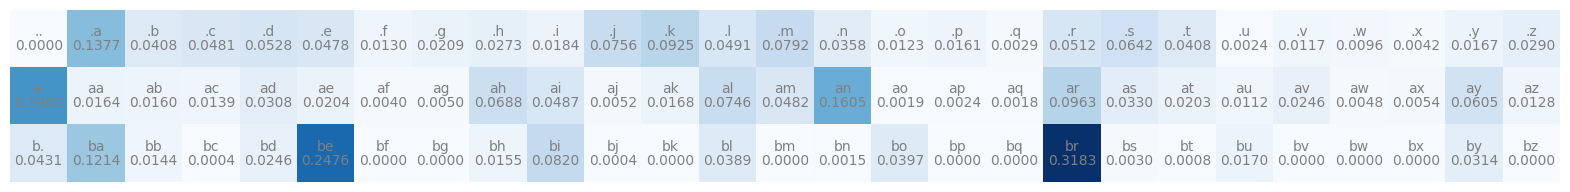

In [87]:
P = (N).float()
P /= P.sum(1, keepdim=True)
plt.figure(figsize=(20, 20))
P = P[:3, :]
plt.imshow(P, cmap='Blues')
for i in range(3):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, f"{P[i, j].item():.4f}", ha="center", va="top", color='gray')
plt.axis('off');

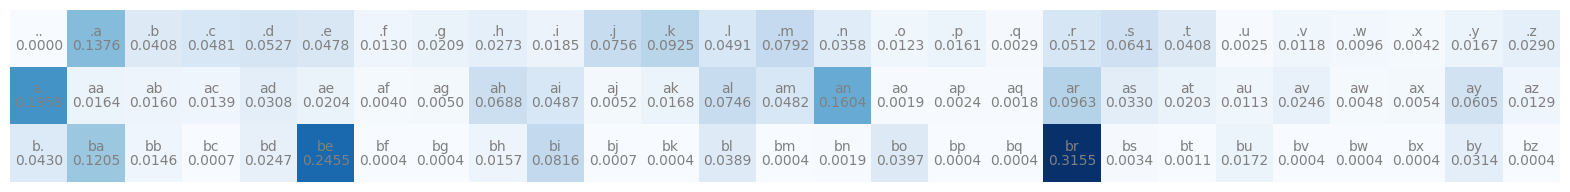

In [88]:
PS1 = (N+1).float()
PS1 /= PS1.sum(1, keepdim=True)
plt.figure(figsize=(20, 20))
PS1 = PS1[:3, :]
plt.imshow(PS1, cmap='Blues')
for i in range(3):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, f"{PS1[i, j].item():.4f}", ha="center", va="top", color='gray')
plt.axis('off');

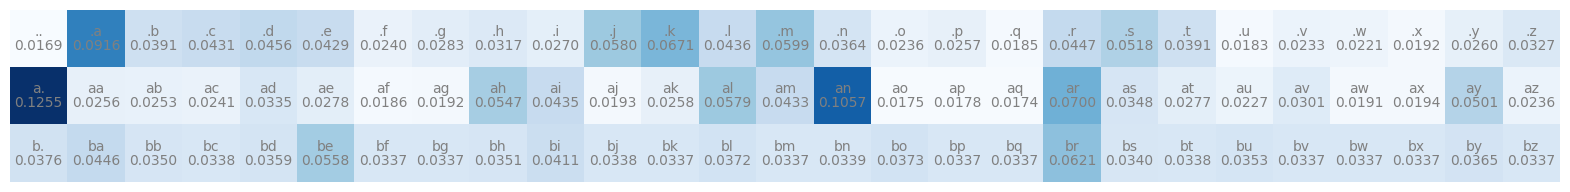

In [89]:
PS = (N+1000).float()
PS /= PS.sum(1, keepdim=True)
plt.figure(figsize=(20, 20))
PS = PS[:3, :]
plt.imshow(PS, cmap='Blues')
for i in range(3):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, f"{PS[i, j].item():.4f}", ha="center", va="top", color='gray')
plt.axis('off');

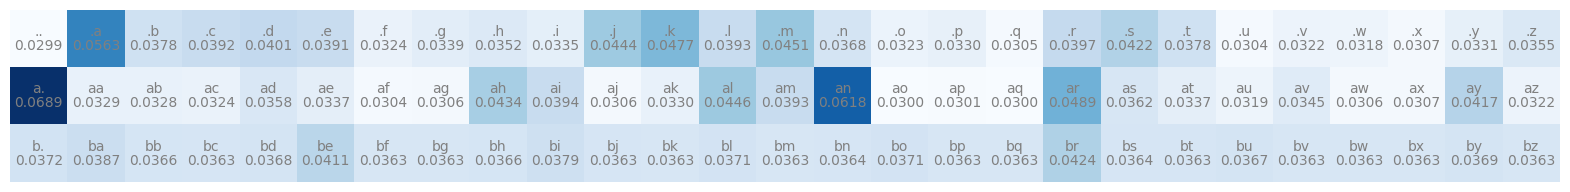

In [90]:
PS5 = (N+5000).float()
PS5 /= PS5.sum(1, keepdim=True)
plt.figure(figsize=(20, 20))
PS5 = PS5[:3, :]
plt.imshow(PS5, cmap='Blues')
for i in range(3):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, f"{PS5[i, j].item():.4f}", ha="center", va="top", color='gray')
plt.axis('off');

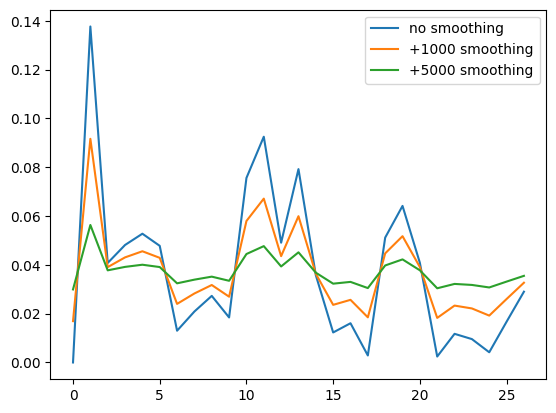

In [92]:
plt.plot(torch.arange(27), P[0], label='no smoothing')
# plt.plot(torch.arange(27), PS1[0], label='+1 smoothing')
plt.plot(torch.arange(27), PS[0], label='+1000 smoothing')
plt.plot(torch.arange(27), PS5[0], label = '+5000 smoothing')
plt.legend() # Displays the labels
plt.show()

So difference between +1 vs +1000 vs +5000 smoothing, in the +5000 version the higher probabilities are squished down and the lower probabilities are extended out.

Making the bell gaussian curve flatter and flatter. This is equivalent to make the spiky weight vector smoother and more rounder (round enough to fit a high dimensional circle). Therefore label smoothing is equivalent to regularization!!



In [ ]:
## Another interpretation to understand the regularization effect

logits = xenc @ W # if W is zero, logits are 0
counts = logits.exp() # which means exponentiating 0 would be all 1's
probs = counts / counts.sum(1, keepdims=True) # which would make the probability distribution uniform i.e all 1/27

## Therefore, regularizing --> which is equivalent to driving W's to zero --> is equivalent to have a uniform probability distribution across all possible outputs

## To that effect, the strength of the regularization constant is analogous to the strength of smoothing
## 0.01 ~ (N + <x>)